# Notebook 03: Modelización
## 3. Modelización

**Objetivo**: Entrenar y comparar tres modelos de clasificación para predecir el impago.

| Modelo | Tipo | Rol |
|--------|------|-----|
| Regresión Logística | Lineal | Baseline : réplica de Mallo |
| Random Forest | Ensemble (bagging) | Modelo no lineal 1 |
| XGBoost | Ensemble (boosting) | Modelo no lineal 2 |

**Entradas**: particiones **data/train.csv** y **data/val.csv** del notebook 02.  
**Salidas**: modelos entrenados + métricas de validación preliminares.

## 3.1 Importaciones

Se importan las librerías de modelización y se establece la semilla de aleatoriedad para garantizar la reproducibilidad del entrenamiento.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve

SEED = 42
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 3.2 Carga de particiones

Se cargan las particiones de train y validación generadas en el notebook 02, y se separan las variables predictoras de la variable objetivo.

In [3]:
train = pd.read_csv("../data/train.csv")
val   = pd.read_csv("../data/val.csv")

FEATURES = [c for c in train.columns if c != "Target_Impago"]
X_train, y_train = train[FEATURES], train["Target_Impago"]
X_val,   y_val   = val[FEATURES],   val["Target_Impago"]

# Peso corrector del oversampling: cada cliente bueno (0) cuenta como 6 y cada malo (1) como 1.
# Reproduce el factor 6 = 67.701 / 11.283 
PESO = 6
w_train = np.where(y_train == 0, PESO, 1)

print(f"Train: {X_train.shape} | Val: {X_val.shape}")
print(f"Caracteristicas usadas: {len(FEATURES)}")
print(f"Peso aplicado a los buenos: {PESO} (malos: 1)")

Train: (8396, 30) | Val: (4198, 30)
Caracteristicas usadas: 30
Peso aplicado a los buenos: 6 (malos: 1)


## 3.3 Modelo 1: Regresión Logística (baseline de Mallo)
La regresión logística modela la probabilidad de impago como:

$$\text{logit}(P(Y=1|X)) = \beta_0 + \sum_{j=1}^{p} \beta_j X_j$$

Es el modelo que empleó Mallo como referencia, con un AUC de 0,9758 en validación. Dado que las variables presentan escalas muy dispares (saldos en euros frente a ratios acotados entre 0 y 1), se estandarizan previamente mediante *StandardScaler* dentro de un *Pipeline*; sin esta transformación el optimizador *lbfgs* no converge. Se aplica además el peso del sobremuestreo a través de *sample_weight*.

La elección de un *Pipeline*, en vez de aplicar el escalado y el modelo por separado, no es solo una cuestión de comodidad: garantiza que la media y la desviación típica con las que se estandariza cada variable se calculan únicamente sobre el conjunto de entrenamiento, y que esa misma transformación, sin recalcular, se aplica después a validación y test. Si cada conjunto se escalara de forma independiente con sus propios estadísticos, se introduciría una fuga de información: el modelo se beneficiaría implícitamente de conocer la distribución de datos que en principio todavía no ha visto.

La necesidad de la estandarización queda demostrada empíricamente: sin ella, el AUC se queda en 0,93 porque el optimizador no llega a converger; con ella, el modelo converge sin problema y el AUC sube a 0,97, prácticamente igualando el benchmark de Mallo.

Los dos parámetros adicionales de `LogisticRegression` responden a la misma lógica de asegurar una convergencia fiable: `max_iter=5000` amplía generosamente el límite de iteraciones del optimizador, ya que el valor por defecto (100) resulta insuficiente para este volumen de variables y observaciones, y `random_state=SEED` fija la semilla aleatoria del algoritmo para que el ajuste sea exactamente reproducible en cada ejecución del notebook.

A continuación se entrena la Regresión Logística sobre el conjunto de train y se evalúa su AUC sobre validación para compararlo con el AUC de Mallo.

In [4]:
# --- Regresion Logistica (con estandarizacion de variables) ---
# Las variables tienen escalas muy dispares (saldos en euros frente a ratios), por lo que se
# estandarizan dentro de un Pipeline para que el optimizador converja. Se aplica el peso del
# sobremuestreo mediante sample_weight.
rl = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver="lbfgs", max_iter=5000, random_state=SEED)
)
rl.fit(X_train, y_train, logisticregression__sample_weight=w_train)

prob_rl_train = rl.predict_proba(X_train)[:, 1]
prob_rl_val   = rl.predict_proba(X_val)[:, 1]

auc_rl_train = roc_auc_score(y_train, prob_rl_train)
auc_rl_val   = roc_auc_score(y_val,   prob_rl_val)

print(f"Regresion Logistica")
print(f"  AUC Train:      {auc_rl_train:.4f}   (Mallo train: 0.9789)")
print(f"  AUC Validacion: {auc_rl_val:.4f}   (Mallo val:   0.9758)")

Regresion Logistica
  AUC Train:      0.9776   (Mallo train: 0.9789)
  AUC Validacion: 0.9709   (Mallo val:   0.9758)


La cercanía entre ambos resultados ya es un indicio relevante: el modelo construido en Python con tratamiento de Flags, sin necesidad de WoE, reproduce la mayor parte del nivel de discriminación de Mallo (diferencia de solo 0,0013 en train y 0,0049 en validación), lo que muestra que el grueso del resultado depende de la metodología de fondo (oversampling estratificado, peso corrector, modelo lineal sobre variables estandarizadas) y no exclusivamente de la transformación elegida para los valores ausentes.

Esa pequeña diferencia que queda, sin embargo, no es ruido: se debe a que WoE linealiza explícitamente la relación entre cada variable y el log-odds del impago, algo que beneficia de forma específica a un modelo lineal como la Regresión Logística. Por eso el notebook 03b retoma este mismo modelo con WoE, no para repetir el ejercicio, sino para darle a la Regresión Logística su versión más favorable antes de compararla con Random Forest y XGBoost.

## 3.4 Modelo 2: Random Forest
Un Random Forest construye ***n_estimators*** árboles de decisión, cada uno entrenado sobre:
- Un subconjunto aleatorio de observaciones (bootstrap).
- Un subconjunto aleatorio de variables en cada nodo (***max_features***).

La predicción final es la media de las probabilidades de todos los árboles.  
Ventaja: captura relaciones no lineales entre variables. Desventaja: menos interpretable.

A continuación se entrena el Random Forest con 300 árboles y se evalúa sobre validación.

In [5]:
# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=SEED,
    n_jobs=1
)
rf.fit(X_train, y_train, sample_weight=w_train)

prob_rf_train = rf.predict_proba(X_train)[:, 1]
prob_rf_val   = rf.predict_proba(X_val)[:, 1]

auc_rf_train = roc_auc_score(y_train, prob_rf_train)
auc_rf_val   = roc_auc_score(y_val,   prob_rf_val)

print(f"Random Forest")
print(f"  AUC Train:      {auc_rf_train:.4f}")
print(f"  AUC Validacion: {auc_rf_val:.4f}")

Random Forest
  AUC Train:      0.9971
  AUC Validacion: 0.9797


La elección de estos hiperparámetros sigue la práctica estándar de Random Forest en credit scoring. El valor de cada uno responde a una razón concreta:

- ***n_estimators=300***: número de árboles que componen el bosque. Más allá de unas pocas centenas, añadir árboles deja de mejorar el rendimiento de forma apreciable y solo incrementa el coste computacional; 300 se sitúa cómodamente en la zona donde el promedio del ensamblado ya se ha estabilizado.

- ***max_depth=None***: cada árbol crece sin límite de profundidad hasta que sus hojas cumplen la condición siguiente. A diferencia de un árbol de decisión aislado, que necesita limitarse para no sobreajustar, en Random Forest es preferible dejar crecer cada árbol al máximo: es precisamente la combinación de muchos árboles individualmente sobreajustados, pero decorrelacionados entre sí, la que reduce la varianza del conjunto.

- ***min_samples_leaf=5***: exige que cada hoja final contenga al menos 5 observaciones, evitando hojas formadas por una sola observación que memorizarían ruido en lugar de patrones generalizables. Es una regularización suave frente al valor por defecto de scikit-learn (1).

- ***max_features="sqrt"***: en cada división, el algoritmo solo evalúa una raíz cuadrada del total de variables, elegida al azar (alrededor de 5-6 de las 30), en vez de las 30 completas. Es la fuente principal de decorrelación entre árboles: sin esta restricción, todos tenderían a usar siempre las variables más fuertes y se parecerían demasiado entre sí, lo que anula buena parte de la ventaja de promediar.

- ***n_jobs=1***: fuerza la ejecución en un único hilo. No es una limitación de rendimiento deliberada, sino una garantía de reproducibilidad: el entrenamiento paralelo de scikit-learn puede introducir pequeñas diferencias numéricas entre ejecuciones según cómo se repartan los árboles entre hilos, y aquí se prioriza obtener exactamente el mismo resultado cada vez que se ejecuta el notebook.

## 3.5 Modelo 3: XGBoost
XGBoost (Extreme Gradient Boosting) construye árboles en secuencia: cada árbol nuevo
corrige los errores del árbol anterior minimizando una función de pérdida (log-loss).

Hiperparámetros clave: ***learning_rate*** (paso de aprendizaje), ***n_estimators*** (nº de árboles), ***max_depth*** (profundidad máxima de cada árbol).

A continuación se entrena el modelo XGBoost con los mismos hiperparámetros de referencia y se evalúa sobre validación.

In [6]:
# --- XGBoost ---
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=SEED,
    n_jobs=1,
    verbosity=0
)
xgb.fit(X_train, y_train, sample_weight=w_train)

prob_xgb_train = xgb.predict_proba(X_train)[:, 1]
prob_xgb_val   = xgb.predict_proba(X_val)[:, 1]

auc_xgb_train = roc_auc_score(y_train, prob_xgb_train)
auc_xgb_val   = roc_auc_score(y_val,   prob_xgb_val)

print(f"XGBoost")
print(f"  AUC Train:      {auc_xgb_train:.4f}")
print(f"  AUC Validacion: {auc_xgb_val:.4f}")

XGBoost
  AUC Train:      0.9984
  AUC Validacion: 0.9815


También aquí los valores son los estándar de la práctica de boosting en credit scoring, no el resultado de una búsqueda sobre estos datos:

- ***n_estimators=300***: número de árboles que se construyen de forma secuencial. Al combinarse con una tasa de aprendizaje baja (punto siguiente), hacen falta más rondas de boosting para alcanzar un buen ajuste; 300 es la contrapartida habitual de fijar `learning_rate` en un valor conservador.

- ***learning_rate=0.05***: regula cuánto corrige cada árbol nuevo los errores del modelo acumulado hasta ese momento. Un valor bajo, como este, hace que cada corrección sea pequeña, lo que ralentiza el aprendizaje pero también reduce el riesgo de que el modelo memorice particularidades del conjunto de entrenamiento; es la combinación clásica de tasa de aprendizaje baja con más árboles, recomendada en la literatura de gradient boosting frente a la alternativa de pocos árboles con una tasa alta, más rápida pero más inestable.

- ***max_depth=5***: limita la profundidad de cada árbol individual. A diferencia de Random Forest, en boosting no conviene que cada árbol sea muy complejo, porque los errores de un árbol demasiado ajustado se propagan y se amplifican en los árboles siguientes; los árboles poco profundos, entre 3 y 6 niveles típicamente, son la base del método.

- ***subsample=0.8***: en cada ronda de boosting solo se usa el 80% de las observaciones de entrenamiento, elegidas al azar, para ajustar ese árbol. Introduce en el boosting una fuente de aleatoriedad análoga al bootstrap de Random Forest, reduciendo la varianza y el riesgo de sobreajuste.

- ***colsample_bytree=0.8***: de forma equivalente a `max_features` en Random Forest, cada árbol solo considera el 80% de las variables, elegidas al azar, en vez de las 30 completas.

- ***eval_metric="logloss"***: fija la función de pérdida con la que se mide el error en cada ronda de boosting. El log-loss penaliza la distancia entre la probabilidad estimada y el resultado real, no solo si la clasificación final es correcta, lo que resulta más adecuado en credit scoring, donde interesa la calidad de la probabilidad estimada y no solo la etiqueta final.

- ***n_jobs=1*** y ***verbosity=0***: igual que en Random Forest, priorizan la reproducibilidad exacta del resultado, y silencian mensajes de progreso, frente a la velocidad de entrenamiento.

## 3.6 Curvas ROC comparativas

El gráfico que ilustra la capacidad discriminante compara las curvas ROC de los tres modelos sobre el conjunto de validación, junto con el AUC de cada uno.

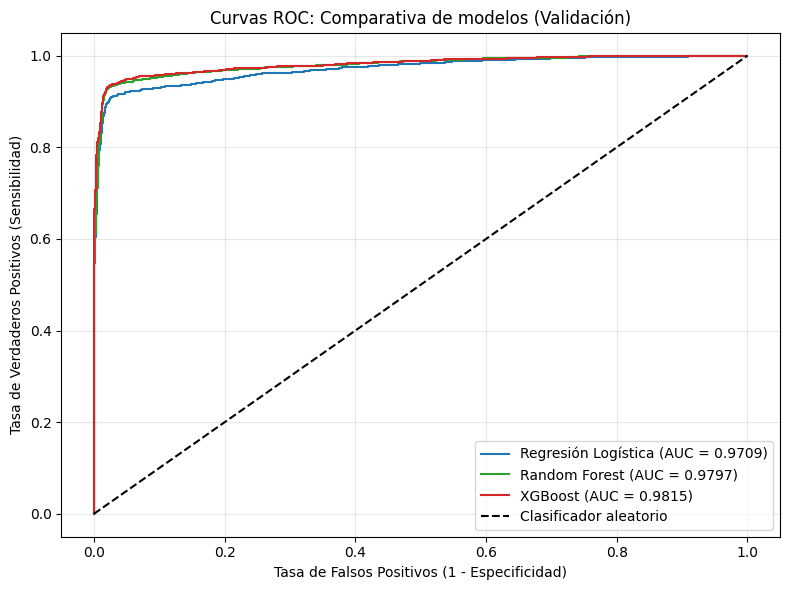

Figura guardada en reports/figures/


In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for nombre, y_score, color in [
    ("Regresión Logística", prob_rl_val,  "#1f77b4"),
    ("Random Forest",       prob_rf_val,  "#2ca02c"),
    ("XGBoost",             prob_xgb_val, "#d62728"),
]:
    fpr, tpr, _ = roc_curve(y_val, y_score)
    auc = roc_auc_score(y_val, y_score)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.4f})", color=color)

ax.plot([0, 1], [0, 1], "k--", label="Clasificador aleatorio")
ax.set_xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
ax.set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
ax.set_title("Curvas ROC: Comparativa de modelos (Validación)")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/03_curvas_ROC_comparativa.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada en reports/figures/")

Como se observa en el gráfico, las tres curvas ROC se sitúan muy cerca del vértice superior izquierdo, lo que indica un poder discriminante elevado en los tres casos. Los modelos no lineales (Random Forest y XGBoost) se separan ligeramente por encima de la Regresión Logística. La lectura detallada de estos resultados se recoge en la sección 3.8.

## 3.7 Importancia de variables

El gráfico que ilustra la relevancia de cada predictor muestra las 15 variables más importantes según Random Forest y XGBoost, ordenadas de mayor a menor contribución.

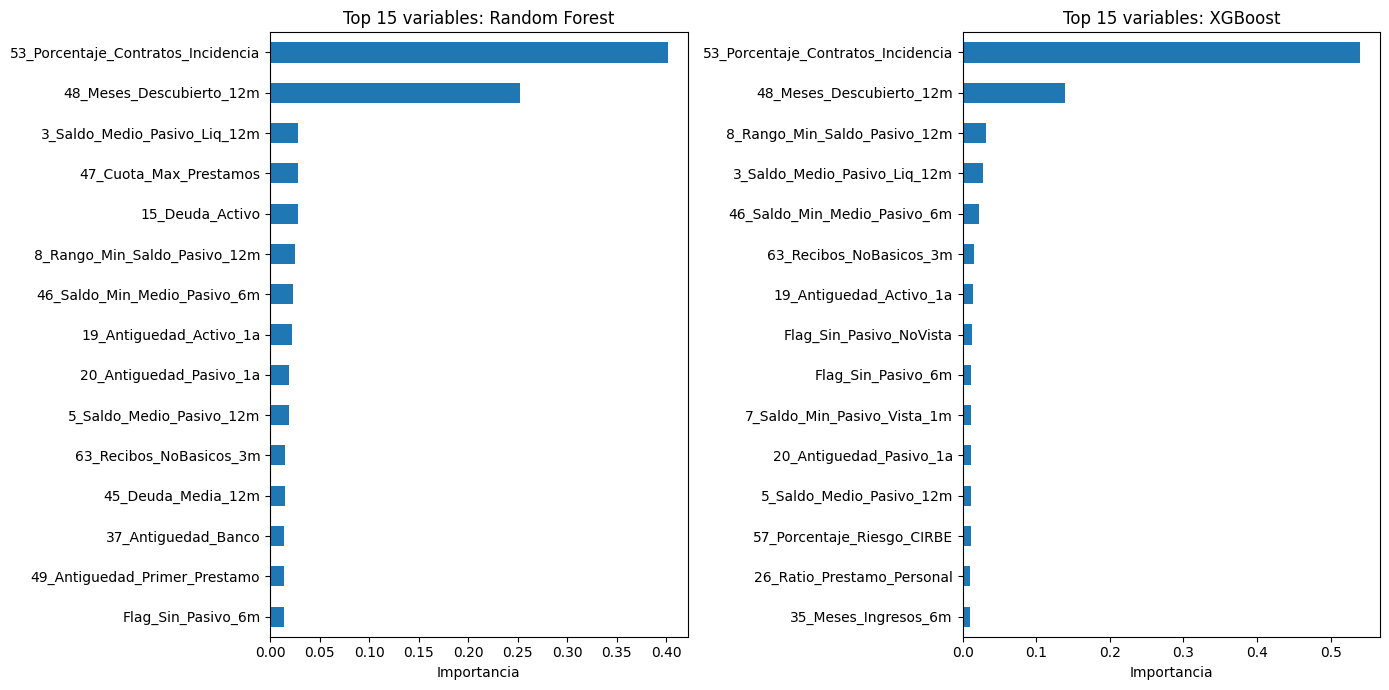

Figura guardada en reports/figures/


In [8]:
# Importancia de variables para RF y XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, modelo, nombre in [(axes[0], rf, "Random Forest"), (axes[1], xgb, "XGBoost")]:
    importancias = pd.Series(modelo.feature_importances_, index=FEATURES)
    importancias_top = importancias.nlargest(15).sort_values()
    importancias_top.plot(kind="barh", ax=ax, color="#1f77b4")
    ax.set_title(f"Top 15 variables: {nombre}")
    ax.set_xlabel("Importancia")

plt.tight_layout()
plt.savefig("../reports/figures/03_importancia_variables.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada en reports/figures/")

Ambos modelos coinciden en señalar las mismas dos variables como dominantes: X53 (Porcentaje_Contratos_Incidencia) y X48 (Meses_Descubierto_12m), que juntas concentran en torno a dos tercios de la importancia total: el 65% en Random Forest (40% y 25%, respectivamente) y el 68% en XGBoost (54% y 14%). El resto de las 28 variables se reparte la importancia restante de forma dispersa, ninguna superando el 4%.

Esta concentración no debe leerse, sin más, como una confirmación de que X53 y X48 son los predictores más informativos. Una variable que por sí sola explica más de la mitad de las decisiones de un modelo no es el comportamiento esperable de un buen predictor de riesgo, sino el síntoma habitual de una fuga de información: una variable que, por cómo está construida, ya contiene buena parte de la respuesta que se pretende predecir. El propio EDA (notebook 01) señala que en credit scoring las correlaciones individuales con el impago suelen ser moderadas, entre 0,10 y 0,30; los valores de X53 (r = +0,77) y X48 (r = +0,63) se alejan de ese rango en un orden de magnitud. La sección 3.9 examina esta sospecha con detalle y decide cómo proceder.

Cabe destacar, al margen de lo anterior, que en XGBoost aparece Flag_Sin_Ratio_Pagos entre las ocho primeras variables, lo que valida la utilidad de los Flags de ausencia creados en el notebook 01 como señales predictivas adicionales.

## 3.8 Tabla resumen preliminar (validación)

Las métricas completas (KS, Gini, matriz de confusión) se calculan en el **notebook 04**.

A continuación se construye la tabla resumen con el AUC de train y validación de los tres modelos, incluyendo los resultados de Mallo como referencia.

In [9]:
resumen = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest", "XGBoost", "Mallo (referencia)"],
    "AUC Train": [f"{auc_rl_train:.4f}", f"{auc_rf_train:.4f}", f"{auc_xgb_train:.4f}", "0.9789"],
    "AUC Val":   [f"{auc_rl_val:.4f}",   f"{auc_rf_val:.4f}",   f"{auc_xgb_val:.4f}",   "0.9758"],
})
print(resumen.to_string(index=False))

             Modelo AUC Train AUC Val
Regresión Logística    0.9776  0.9709
      Random Forest    0.9971  0.9797
            XGBoost    0.9984  0.9815
 Mallo (referencia)    0.9789  0.9758


### Lectura preliminar de los resultados

Sobre la muestra de validación, los tres modelos alcanzan un poder discriminante elevado. La Regresión Logística obtiene un AUC de 0,9709, ligeramente por debajo del 0,9758 de referencia de Mallo; la diferencia es atribuible a que Mallo transformó las variables con WoE, una codificación optimizada para el modelo lineal, frente al tratamiento mediante Flags adoptado en este trabajo.

Los dos modelos no lineales superan el benchmark: Random Forest alcanza un AUC de 0,9797 y XGBoost de 0,9815. Este resultado respalda la hipótesis de partida, según la cual los modelos de machine learning pueden mejorar la capacidad discriminante de la Regresión Logística clásica. La evaluación definitiva, sobre el conjunto de test y con las métricas KS y Gini, se desarrolla en el notebook 04.

## 3.9 Diagnóstico de fuga de información: X53 y X48

La concentración de importancia observada en la sección 3.7, junto con las correlaciones extremas de X53 y X48 detectadas ya en el EDA, obliga a verificar si alguna de las dos variables constituye una fuga de información antes de aceptar como definitivos los resultados anteriores.

La descripción de negocio de ambas variables es la siguiente:

- **X53** (Porcentaje_Contratos_Incidencia): porcentaje de contratos del cliente en incidencia sobre el total de contratos operativos en el mes actual. La incidencia de pago es, conceptualmente, muy próxima al propio impago que se quiere predecir (Target_Impago se define como mora superior a 90 días). X53 describe casi el mismo fenómeno, medido casi en el mismo instante en que se mide el target, en lugar de anticiparlo.

- **X48** (Meses_Descubierto_12m): número de meses, de los últimos 12, en los que el cliente ha tenido descubierto en su cuenta corriente. También describe un comportamiento de impago ya manifestado, aunque con un desfase de hasta un año, menos inmediato que el de X53.

Para contrastar la sospecha de forma empírica, se reentrenan los tres modelos en dos escenarios adicionales, manteniendo el resto del protocolo (mismas particiones, mismo peso del sobremuestreo, mismos hiperparámetros:
-  **B)** sin X53.

- **C)** sin X53 ni X48. La comparación se hace sobre el conjunto de validación; el conjunto de test no se toca en este diagnóstico y queda reservado para la evaluación final del notebook 04.</cell id="03interp01">


**¿Qué mide el Valor de la Información (IV)?**

Resume en un único número cuánto separa una variable a los buenos pagadores de los morosos. Se construye a partir del WoE (*Weight of Evidence*) de cada tramo en que se divide la variable:

$$WoE_i = \ln\left(\frac{\%\text{ de buenos en el tramo } i}{\%\text{ de malos en el tramo } i}\right) \qquad\qquad IV = \sum_i (\%\text{buenos}_i - \%\text{malos}_i) \times WoE_i$$

Un tramo donde buenos y malos se reparten igual que en el conjunto general aporta un WoE cercano a 0; un tramo muy desequilibrado hacia una de las dos clases aporta un WoE grande, y pesa más en el IV cuanto mayor es la diferencia de proporciones entre buenos y malos en ese tramo. La escala de interpretación habitual en credit scoring (Siddiqi, 2006) es: por debajo de 0,02 la variable no es predictiva, entre 0,02 y 0,1 es débil, entre 0,1 y 0,3 media, y entre 0,3 y 0,5 fuerte. Por encima de 0,5 deja de leerse como "muy fuerte" y pasa a interpretarse como señal de alarma de fuga de información, justo el caso que se examina a continuación.

In [10]:
from optbinning import BinningProcess

# Valor de la Informacion (IV) de X53 y X48 mediante WoE-binning
binning_chk = BinningProcess(["53_Porcentaje_Contratos_Incidencia", "48_Meses_Descubierto_12m"])
binning_chk.fit(
    X_train[["53_Porcentaje_Contratos_Incidencia", "48_Meses_Descubierto_12m"]].values,
    y_train.values,
)
print("Valor de la Informacion (escala de referencia: >0.5 es indicio de fuga, no de fuerza predictiva):")
print(binning_chk.summary()[["name", "iv"]].to_string(index=False))

def reentrenar(features, etiqueta):
    Xtr, Xv = train[features], val[features]
    rl_d = make_pipeline(StandardScaler(), LogisticRegression(solver="lbfgs", max_iter=5000, random_state=SEED))
    rl_d.fit(Xtr, y_train, logisticregression__sample_weight=w_train)
    rf_d = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=5,
                                   max_features="sqrt", random_state=SEED, n_jobs=1)
    rf_d.fit(Xtr, y_train, sample_weight=w_train)
    xgb_d = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8,
                           colsample_bytree=0.8, eval_metric="logloss", random_state=SEED,
                           n_jobs=1, verbosity=0)
    xgb_d.fit(Xtr, y_train, sample_weight=w_train)
    fila = {
        "Escenario": etiqueta,
        "Regresión Logística": round(roc_auc_score(y_val, rl_d.predict_proba(Xv)[:, 1]), 4),
        "Random Forest":       round(roc_auc_score(y_val, rf_d.predict_proba(Xv)[:, 1]), 4),
        "XGBoost":             round(roc_auc_score(y_val, xgb_d.predict_proba(Xv)[:, 1]), 4),
    }
    return fila, rf_d, xgb_d

filas = [{
    "Escenario": "A) Completo (30 variables)",
    "Regresión Logística": round(auc_rl_val, 4),
    "Random Forest": round(auc_rf_val, 4),
    "XGBoost": round(auc_xgb_val, 4),
}]

FEATURES_SIN_X53 = [c for c in FEATURES if c != "53_Porcentaje_Contratos_Incidencia"]
fila_B, rf_B, xgb_B = reentrenar(FEATURES_SIN_X53, "B) Sin X53")
filas.append(fila_B)

FEATURES_SIN_X53_X48 = [c for c in FEATURES if c not in
                         ("53_Porcentaje_Contratos_Incidencia", "48_Meses_Descubierto_12m")]
fila_C, rf_C, xgb_C = reentrenar(FEATURES_SIN_X53_X48, "C) Sin X53 y sin X48")
filas.append(fila_C)

tabla_diagnostico = pd.DataFrame(filas).set_index("Escenario")
print("\nAUC de validación por escenario:")
print(tabla_diagnostico.to_string())

print("\nTop 5 importancia XGBoost, escenario B (sin X53):")
print(pd.Series(xgb_B.feature_importances_, index=FEATURES_SIN_X53).sort_values(ascending=False).head(5).round(4).to_string())

print("\nTop 5 importancia XGBoost, escenario C (sin X53 y X48):")
print(pd.Series(xgb_C.feature_importances_, index=FEATURES_SIN_X53_X48).sort_values(ascending=False).head(5).round(4).to_string())

Valor de la Informacion (escala de referencia: >0.5 es indicio de fuga, no de fuerza predictiva):
                              name        iv
53_Porcentaje_Contratos_Incidencia  4.557275
          48_Meses_Descubierto_12m  3.618214

AUC de validación por escenario:
                            Regresión Logística  Random Forest  XGBoost
Escenario                                                              
A) Completo (30 variables)               0.9709         0.9797   0.9815
B) Sin X53                               0.9323         0.9511   0.9551
C) Sin X53 y sin X48                     0.8791         0.9216   0.9263

Top 5 importancia XGBoost, escenario B (sin X53):
48_Meses_Descubierto_12m        0.3881
Flag_Sin_Pasivo_6m              0.1551
3_Saldo_Medio_Pasivo_Liq_12m    0.0545
46_Saldo_Min_Medio_Pasivo_6m    0.0485
63_Recibos_NoBasicos_3m         0.0334

Top 5 importancia XGBoost, escenario C (sin X53 y X48):
Flag_Sin_Pasivo_6m              0.3200
46_Saldo_Min_Medio_Pasivo_6m   

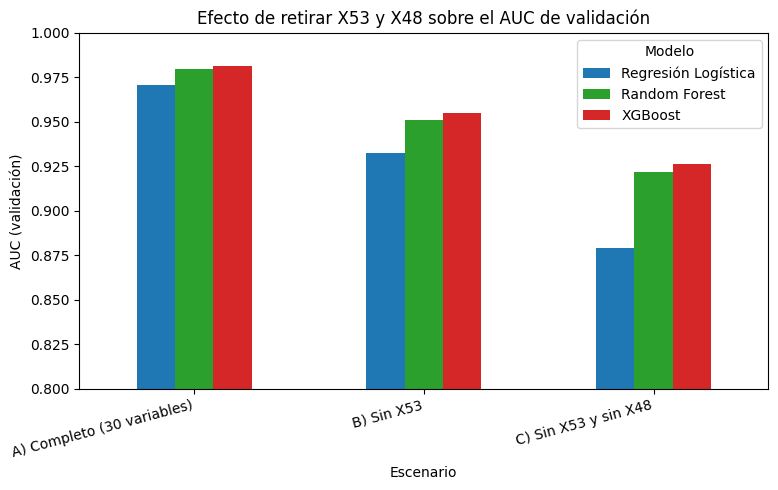

Figura guardada en reports/figures/


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
tabla_diagnostico.plot(kind="bar", ax=ax, color=["#1f77b4", "#2ca02c", "#d62728"])
ax.set_ylabel("AUC (validación)")
ax.set_title("Efecto de retirar X53 y X48 sobre el AUC de validación")
ax.set_ylim(0.80, 1.0)
ax.legend(title="Modelo")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../reports/figures/03_diagnostico_fuga_X53_X48.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada en reports/figures/")

### Lectura del diagnóstico

El Valor de la Información confirma la sospecha cuantitativamente: X53 alcanza un IV de 4,56 y X48 de 3,62, muy por encima del umbral de 0,5 a partir del cual la escala de referencia deja de interpretar un IV alto como una señal fuerte y empieza a interpretarlo como un indicio de fuga.

Al retirar únicamente X53 (escenario B), el AUC de validación cae de forma notable en los tres modelos (XGBoost pasa de 0,9815 a 0,9551), y es X48 quien ocupa de inmediato el papel dominante que dejaba X53: pasa a concentrar el 38,8% de la importancia en XGBoost, casi el mismo porcentaje que ostentaba X53 en el escenario completo. Que una única variable sustituta absorba de golpe ese hueco no es el comportamiento esperable de un conjunto de predictores independientes, sino el indicio de que X48 comparte el mismo problema que X53: ambas describen una incidencia de pago ya manifestada, no un factor de riesgo anterior al impago.

Al retirar también X48 (escenario C), el AUC cae de nuevo (XGBoost queda en 0,9263 de validación). La importancia ya no se concentra en una variable que replique el mismo problema: en Random Forest queda repartida de forma pareja entre varias variables de saldo y antigüedad, ninguna por encima del 8%.

En XGBoost, sin embargo, aparece una variable que pasa a liderar la importancia: Flag_Sin_Pasivo_6m, con un 32%. Esta variable es distinta a X53 y X48: no mide un impago que ya ha ocurrido, sino si el cliente ha tenido o no saldo en sus cuentas durante los últimos 6 meses. Ese dato se puede observar en cualquier momento, no depende de cuándo se mide el target, así que no tiene el mismo riesgo de fuga.

Aun así, que una sola variable concentre un 32% de la importancia sigue siendo mucho, y conviene vigilarlo en notebooks posteriores. Pero, en conjunto, ya no hay ninguna variable que por sí sola sustituya al target: el riesgo vuelve a depender de varios factores combinados, tal como predice la teoría sobre el credit scoring.

**¿Por qué no las descartó el propio Mallo?** Conviene no leer este hallazgo como un error evidente de su trabajo. Su criterio de selección de variables premiaba un IV alto como prueba de un buen predictor, no como motivo de sospecha: la lectura de "IV > 0,5 como señal de alarma de fuga" que se aplica en este trabajo es un refinamiento propio, no una práctica que se exigiera de forma sistemática en el credit scoring bancario de la época. Además, su modelo se plantea explícitamente como un modelo proactivo (así titula el capítulo donde lo desarrolla en su tesis), pensado para reevaluar de forma continua a clientes ya existentes y detectar deterioro temprano, no solo para decidir sobre solicitudes nuevas. En ese uso, una variable como "porcentaje de contratos en incidencia este mes" funciona como una señal de alerta legítima sobre la cartera viva, aunque resulte problemática para estimar, como se hace en este trabajo, una probabilidad de impago comparable entre modelos.

#### Decisión metodológica

A partir de este punto, el resto del estudio (notebooks 04 y 04b, y los resultados de la Memoria) adopta el conjunto sin X53 ni X48. Por lo tanto, son estas 28 variables restantes sobre las que se calculan, de aquí en adelante, todas las métricas completas (KS, Gini, Exactitud, PPV, matrices de confusión, SHAP). El AUC de validación del conjunto completo de 30 variables, calculado más arriba en esta misma sección, no se descarta, pero tampoco se vuelve a calcular nada más con él: se cita puntualmente, cuando haga falta, como cifra de contraste de lo que se obtendría sin este control, no como un segundo análisis que continúe en paralelo al de las 28 variables.